# CART Decision Tree Classification
## Predicting Heart Disease

In this project, a Decision Tree Classification model was developed to predict the presence of heart disease based on various clinical indicators such as fasting blood sugar, maximum heart rate, exercise-induced angina, and cholesterol levels. The dataset was preprocessed to ensure consistency and reliability, and the model was trained and evaluated to understand how different medical features contribute to heart disease prediction and how effectively the Decision Tree can capture complex patterns in clinical data.

## Data Dictionary

| Column Name | Description |
|---|---|
| **Age** | Age of the patient in years (29–77). Numerical feature. |
| **Sex** | Biological sex of the patient (0 = Female, 1 = Male). Binary categorical feature. |
| **ChestPainType** | Type of chest pain experienced (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic). Categorical feature. |
| **RestingBP** | Resting blood pressure in mm Hg (94–200). Numerical feature. |
| **Cholesterol** | Serum cholesterol level in mg/dL (126–400). Numerical feature. |
| **FastingBS** | Fasting blood sugar > 120 mg/dL (0 = No, 1 = Yes). Binary categorical feature. |
| **RestingECG** | Resting electrocardiogram result (0 = Normal, 1 = ST-T Wave Abnormality, 2 = Left Ventricular Hypertrophy). Categorical feature. |
| **MaxHR** | Maximum heart rate achieved during exercise test (71–202). Numerical feature. |
| **ExerciseAngina** | Whether the patient experienced exercise-induced angina (0 = No, 1 = Yes). Binary categorical feature. |
| **Oldpeak** | ST depression induced by exercise relative to rest (0.0–6.2). Numerical feature. |
| **ST_Slope** | Slope of the peak exercise ST segment (0 = Down, 1 = Flat, 2 = Up). Categorical feature. |
| **HeartDisease** | Presence of heart disease — target variable (0 = No, 1 = Yes). Binary target. |

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
from google.colab import files
uploaded = files.upload()

# Importing the dataset
df=pd.read_csv('heart_disease.csv',sep=',')

Saving heart_disease.csv to heart_disease (2).csv


# Dataset overview and basic statistics

In [3]:
df.head()
# First 5 rows

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,58,0,1,94,382,0,1,169,1,3.4,1,0
1,73,0,2,119,238,0,2,202,0,2.8,2,1
2,45,1,0,94,400,0,1,121,1,3.5,0,0
3,62,1,2,123,400,1,2,202,0,6.2,1,1
4,77,1,1,94,264,0,2,165,1,5.3,1,0


In [4]:
df.shape
# Shape of dataset (rows,columns)

(1500, 12)

This dataset contains 12 columns and 1500 rows.

In [5]:
df.info()
# The columns and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1500 non-null   int64  
 1   Sex             1500 non-null   int64  
 2   ChestPainType   1500 non-null   int64  
 3   RestingBP       1500 non-null   int64  
 4   Cholesterol     1500 non-null   int64  
 5   FastingBS       1500 non-null   int64  
 6   RestingECG      1500 non-null   int64  
 7   MaxHR           1500 non-null   int64  
 8   ExerciseAngina  1500 non-null   int64  
 9   Oldpeak         1500 non-null   float64
 10  ST_Slope        1500 non-null   int64  
 11  HeartDisease    1500 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 140.8 KB


All data types are correct, so we don't need to change any of them.

In [6]:
df.duplicated().sum()
# Checking duplicate rows

np.int64(0)

The dataset is clean and contains only unique records.

In [7]:
df.isnull().sum()
# Do we have null values or not

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


We don't have null values, so we don't need to drop or fill any columns.

In [8]:
df['HeartDisease'].value_counts(normalize=True)

,proportion
HeartDisease,
0,0.502667
1,0.497333


Since the proportions of the two classes are nearly equal, the dataset can be considered balanced. This is beneficial for classification tasks because the model has a similar number of examples from each class during training, reducing the risk of bias toward one class.

In [9]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000
mean,48.139333,0.502667,1.569333,107.305333,282.226667,0.298667,1.024000,161.493333,0.46200,2.761933,0.902667,0.497333
std,18.746472,0.500160,0.706299,17.826496,95.292811,0.457826,0.552232,40.268387,0.49872,2.161075,0.534213,0.500160
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.00000,0.000000,0.000000,0.000000
25%,29.000000,0.000000,1.000000,94.000000,203.000000,0.000000,1.000000,134.000000,0.00000,0.500000,1.000000,0.000000
50%,45.000000,1.000000,2.000000,99.000000,297.000000,0.000000,1.000000,172.000000,0.00000,2.800000,1.000000,0.000000
75%,67.000000,1.000000,2.000000,116.000000,372.250000,1.000000,1.000000,202.000000,1.00000,4.500000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,400.000000,1.000000,2.000000,202.000000,1.00000,6.200000,2.000000,1.000000


The average age is 48.14 years, with values ranging from 29 to 77 years. The mean resting blood pressure is 107.31 mmHg, the average cholesterol level is 282.23 mg/dL, and the average maximum heart rate is 161.49 bpm. The target variable has a mean value of 0.497, indicating that approximately 49.7% of the observations belong to the positive class. This confirms that the dataset is balanced, making it suitable for classification tasks.

In [10]:
df.dtypes
# Rechecking data types

,0
Age,int64
Sex,int64
ChestPainType,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64


## Exploratory Data Analysis (EDA)

In [11]:
# Numerical and categorical features
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categorical Features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


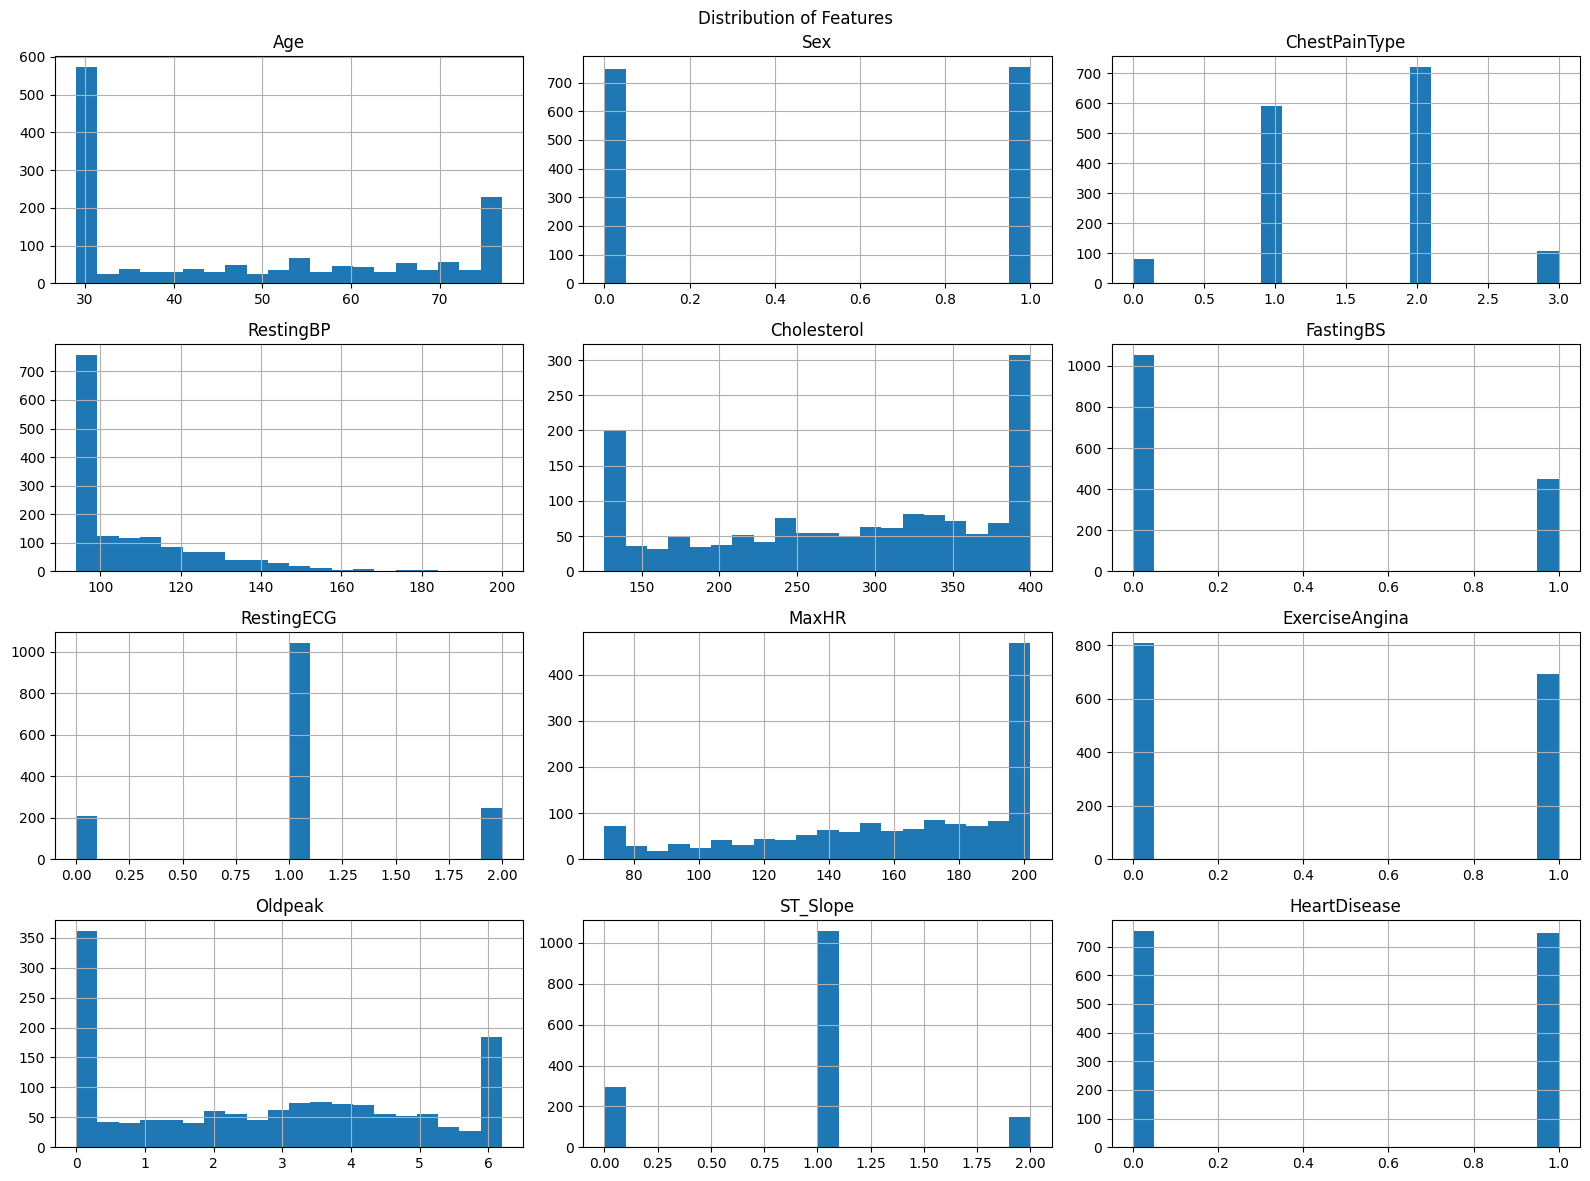

In [12]:
# Check whether data follows a normal distribution and identify skewness and outliers
df.hist(bins=20, figsize=(16,12))
plt.suptitle('Distribution of Features')
plt.tight_layout()
plt.show()

Age appears bimodal, while RestingBP, Cholesterol, and Oldpeak are positively skewed. In contrast, MaxHR is negatively skewed, with most observations concentrated at higher values. Among the categorical variables, Sex is nearly balanced, whereas FastingBS is dominated by category 0. ChestPainType, RestingECG, and ST_Slope are unevenly distributed across their categories, with some categories occurring much more frequently than others. The binary variables ExerciseAngina and HeartDisease are relatively balanced between their two classes. Overall, none of the continuous variables follow a clear normal (bell-shaped) distribution, and no strong bimodal patterns are observed except for Age. Since Decision Trees do not require normally distributed data, these distribution characteristics are unlikely to negatively affect model performance.

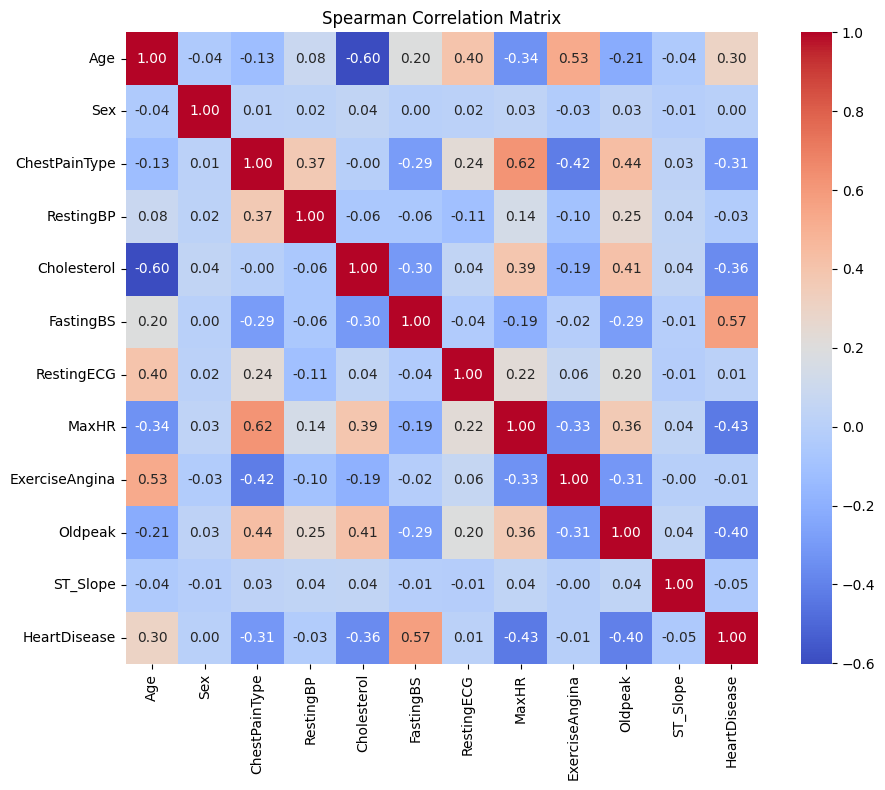

In [13]:
corr_matrix = df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

FastingBS has the strongest positive correlation with HeartDisease, suggesting that higher fasting blood sugar levels are associated with an increased likelihood of heart disease. Age also has a moderate positive correlation with the target, indicating that the risk of heart disease tends to increase with age.

On the other hand, MaxHR, Oldpeak, Cholesterol, and ChestPainType show moderate negative correlations with HeartDisease. These variables may therefore play an important role in distinguishing between patients with and without heart disease. In contrast, Sex, RestingBP, RestingECG, ExerciseAngina, and ST_Slope have very weak correlations with the target.

## DecisionTree Classifier Model Training

In [14]:
# Splitting Data into Training and Testing Sets
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=99)

We split the dataset into training (80%) and testing (20%) sets, where the model is trained on the training data and evaluated on the test data to measure its performance.

In [15]:
# Verify class distribution after train-test split
print("\nOriginal class distribution:")
print(y.value_counts(normalize=True))
print("\n------------------------------------------------")
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print("\n------------------------------------------------")
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))


Original class distribution:
HeartDisease
0    0.502667
1    0.497333
Name: proportion, dtype: float64

------------------------------------------------

Training set class distribution:
HeartDisease
0    0.5025
1    0.4975
Name: proportion, dtype: float64

------------------------------------------------

Testing set class distribution:
HeartDisease
0    0.503333
1    0.496667
Name: proportion, dtype: float64


The class distribution was checked after the train-test split to ensure that the proportion of patients with and without heart disease remained consistent across both subsets. This confirms that the stratified sampling procedure was applied correctly and that the training and testing sets are representative of the original dataset.

In [16]:
# Initialize and train the baseline Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
# Cross-Validation Accuracy
cv_accuracy = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print("Accuracy scores per fold:", cv_accuracy)
print("Mean Accuracy:", np.mean(cv_accuracy))
print("Std Accuracy:", np.std(cv_accuracy))

Accuracy scores per fold: [0.85       0.825      0.82083333 0.85416667 0.87916667]
Mean Accuracy: 0.8458333333333332
Std Accuracy: 0.021245914639969943


In [18]:
# Cross-Validation ROC-AUC
cv_roc_auc = cross_val_score(clf, X_train, y_train, cv=5, scoring='roc_auc')
print("ROC-AUC scores per fold:", cv_roc_auc)
print("Mean ROC-AUC:", np.mean(cv_roc_auc))
print("Std ROC-AUC:", np.std(cv_roc_auc))

ROC-AUC scores per fold: [0.85       0.825      0.82099451 0.85391347 0.87926245]
Mean ROC-AUC: 0.8458340857003958
Std ROC-AUC: 0.02121862466493179


The baseline Decision Tree achieved a mean cross-validation accuracy of 84.58% and a mean ROC-AUC of 84.58%. The relatively low standard deviations indicate that the model performs consistently across the five folds. Although the results are reasonably strong, the model uses the default unpruned settings, which may lead to overfitting by creating an overly complex tree that captures noise in the training data. Therefore, hyperparameter tuning and pruning techniques should be applied to improve the model's generalization performance on unseen data.

In [19]:
# Perform hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_}")

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.8825000000000001


With these hyperparameters, the model achieved a best cross-validation accuracy of 88.25%, which is higher than the baseline accuracy of 84.58%. This improvement suggests that limiting the tree depth and increasing the minimum number of samples in leaf nodes helped reduce overfitting and improved the model’s ability to generalize to unseen data.

In [20]:
# Generate training and validation scores for varying max_depth values
param_range = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

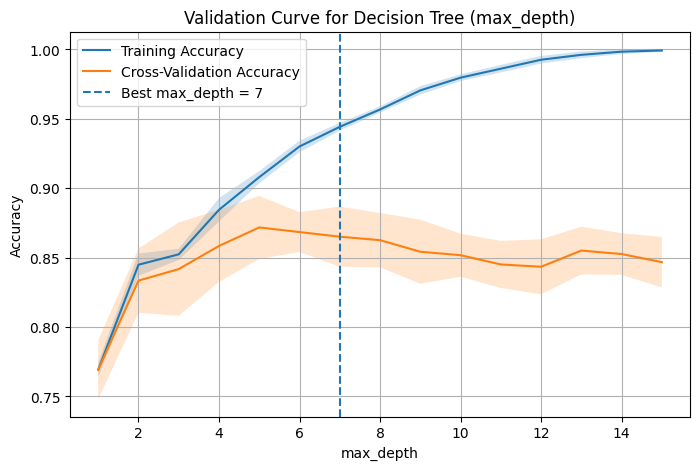

In [21]:
# Visualize training and cross-validation accuracy across different max_depth values
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, label="Training Accuracy")
plt.plot(param_range, val_mean, label="Cross-Validation Accuracy")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2)
best_depth = 7
plt.axvline(x=best_depth, linestyle="--", label=f"Best max_depth = {best_depth}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve for Decision Tree (max_depth)")
plt.legend()
plt.grid(True)
plt.show()

The validation curve shows a clear bias–variance tradeoff. At low max_depth values, the model underfits the data (high bias), resulting in lower training and validation accuracy. As max_depth increases, performance improves and reaches its best level around max_depth = 7. Beyond this point, training accuracy continues to increase while validation accuracy slightly decreases, indicating overfitting (high variance). Therefore, max_depth = 7 provides a good balance between bias and variance.

## Model Evaluation

In [22]:
# Evaluate model performance using multiple classification metrics
final_model = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=8, min_samples_split=2, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.86
Precision: 0.8962962962962963
Recall: 0.8120805369127517
F1 Score: 0.852112676056338
ROC-AUC Score: 0.9233299257744789

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       151
           1       0.90      0.81      0.85       149

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300



The high ROC-AUC value indicates that the model has a strong ability to distinguish between patients with and without heart disease. The classification report shows balanced performance across both classes, with slightly higher precision than recall for the positive class.

Comparing the results, the final test accuracy (86.0%) is slightly higher than the initial cross-validation accuracy (84.58%), demonstrating an improvement after hyperparameter tuning. However, it is slightly lower than the best GridSearchCV cross-validation accuracy (88.25%), which is expected because cross-validation performance is estimated on training folds, while the test accuracy is measured on completely unseen data. Overall, the relatively small difference suggests that the tuned model generalizes well and does not suffer from severe overfitting.

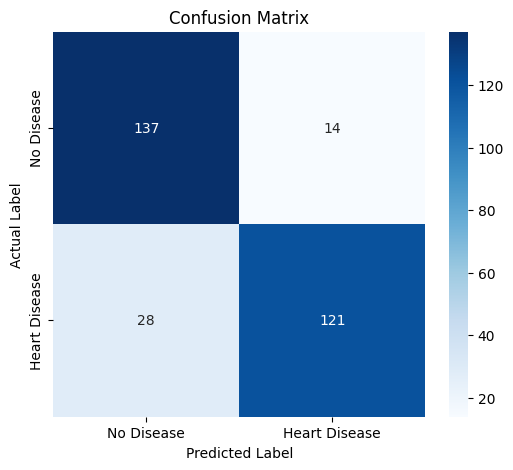

In [23]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Heart Disease'], yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

The model correctly classified 137 patients without heart disease and 121 patients with heart disease. However, 14 healthy individuals were incorrectly predicted as having heart disease (False Positives), while 28 patients with heart disease were incorrectly classified as healthy (False Negatives). Since false negatives represent missed diagnoses, they are considered the more serious error in medical applications. Although the model demonstrates good overall classification performance, reducing the number of false negatives would further improve its clinical usefulness.

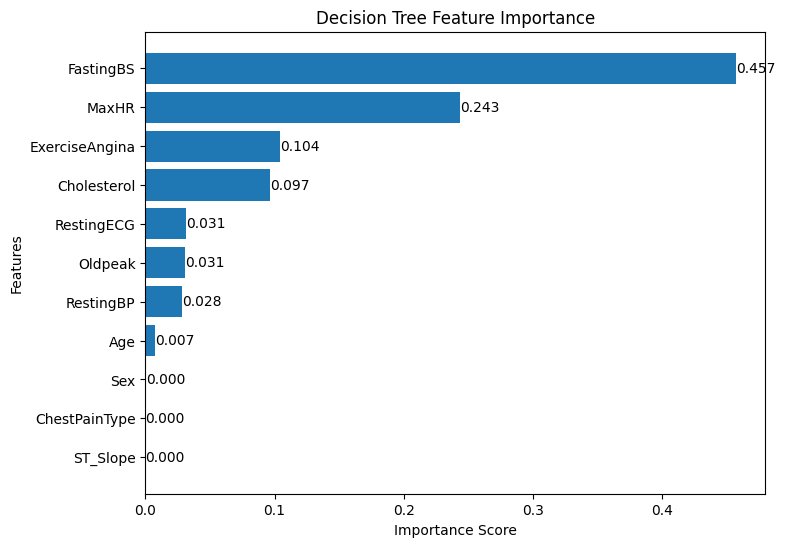

In [24]:
# Visualize feature importance scores
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': final_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'])
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center'
    )
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()

FastingBS is the most influential predictor of the total feature importance in the model. This is followed by MaxHR, ExerciseAngina, and Cholesterol, indicating that these features play the largest role in classifying heart disease. Features such as RestingECG, Oldpeak, and RestingBP contribute relatively little to the model, while Age and Sex have minimal influence.

Notably, ChestPainType and ST_Slope have an importance score of 0.0, meaning they were not used in any splits in the Decision Tree and therefore did not contribute to the model’s predictions. Since feature importance values are normalized to sum to 1.0, higher values indicate features that contribute more to reducing Gini impurity and provide greater predictive power.

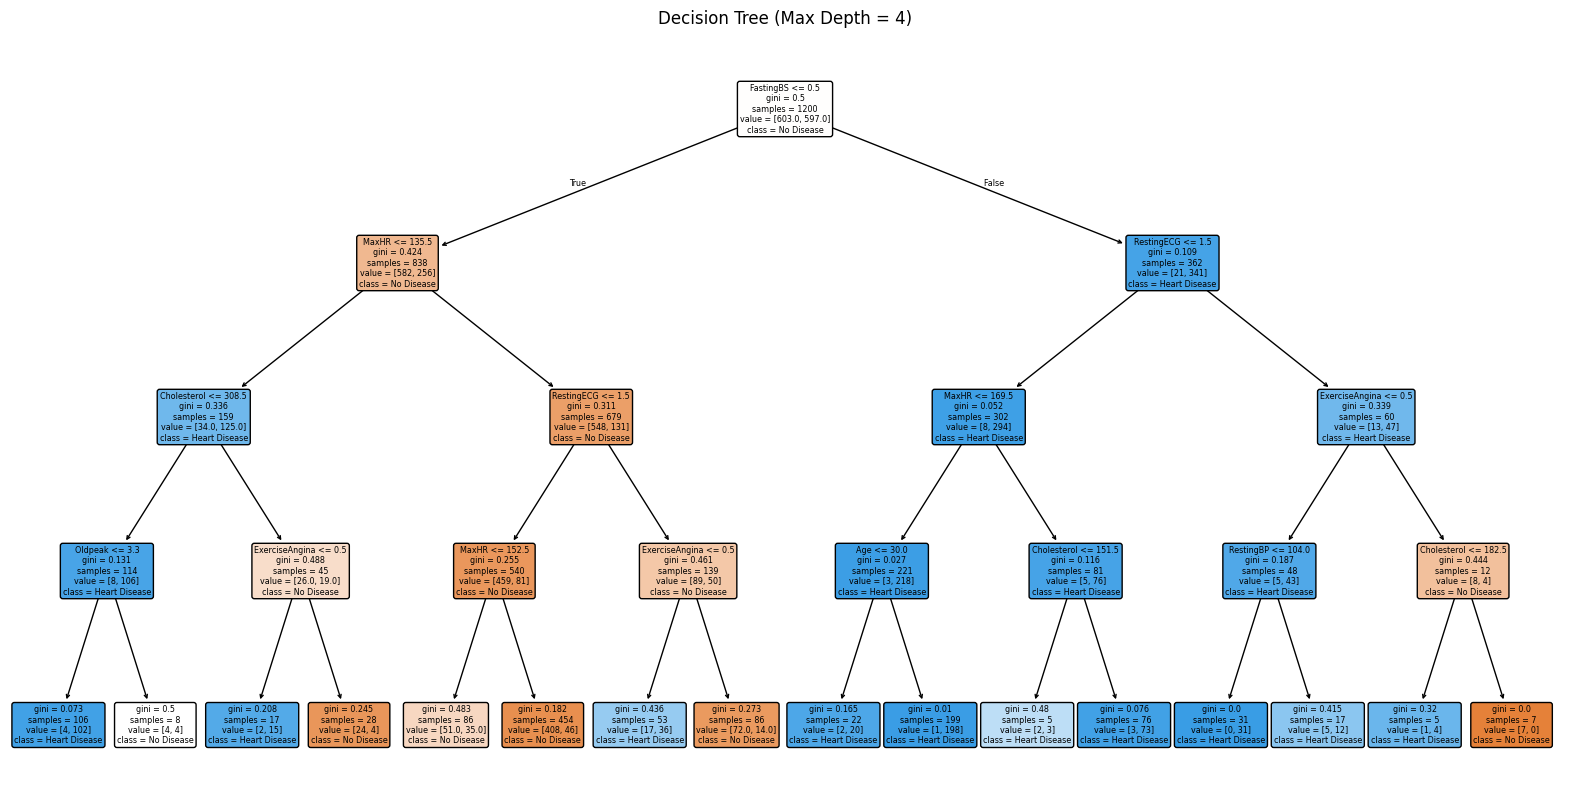

In [25]:
# Decision Tree Visualization
tree_vis = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_vis.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(tree_vis, feature_names=X.columns, class_names=['No Disease', 'Heart Disease'], filled=True, rounded=True)
plt.title("Decision Tree (Max Depth = 4)")
plt.show()

In [26]:
# The first 3 levels as a text-based tree.
tree_rules = export_text(tree_vis, feature_names=list(X.columns))
def print_first_levels(tree, max_depth=3):
    rules = export_text(tree, feature_names=list(X.columns))
    lines = rules.split("\n")
    for line in lines:
        depth = line.count("|")
        if depth <= max_depth:
            print(line)
print_first_levels(tree_vis, max_depth=3)

|--- FastingBS <= 0.50
|   |--- MaxHR <= 135.50
|   |   |--- Cholesterol <= 308.50
|   |   |--- Cholesterol >  308.50
|   |--- MaxHR >  135.50
|   |   |--- RestingECG <= 1.50
|   |   |--- RestingECG >  1.50
|--- FastingBS >  0.50
|   |--- RestingECG <= 1.50
|   |   |--- MaxHR <= 169.50
|   |   |--- MaxHR >  169.50
|   |--- RestingECG >  1.50
|   |   |--- ExerciseAngina <= 0.50
|   |   |--- ExerciseAngina >  0.50



Each internal node of the decision tree shows a feature-based split condition (e.g., FastingBS ≤ 0.50) that divides the dataset into more homogeneous subsets, along with information such as Gini impurity, the number of samples reaching that node, and the class distribution at that point. These values indicate how pure or mixed the data is after each split and how many training examples are involved in that decision.

Each leaf node represents the final outcome of the decision process, where no further splitting occurs, and the predicted class (No Disease or Heart Disease) is assigned based on the majority class of the samples in that region of the tree.

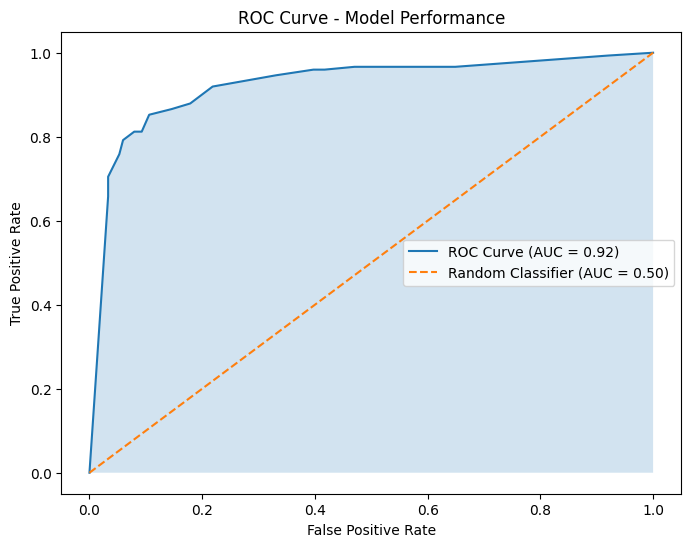

In [27]:
# ROC Curve Analysis
y_proba = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier (AUC = 0.50)")
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Performance")
plt.legend()
plt.show()

The model has an AUC score of approximately 0.92, which indicates strong discriminative power, meaning it can effectively distinguish between patients with and without heart disease and performs significantly better than random guessing (AUC = 0.5).

# Conclusion

In conclusion, The model demonstrated strong performance across multiple evaluation metrics, achieving high accuracy, precision, recall, and an F1 score, indicating a good balance between correctly identifying both positive and negative cases. Additionally, the ROC-AUC score of approximately 0.92 confirmed that the model has strong discriminative ability and performs significantly better than random guessing.

Overall, the results suggest that the Decision Tree model is effective for heart disease prediction, with reliable predictive power and good interpretability, making it suitable for understanding key risk factors in the dataset.